# PROfit AMR-surface contour plotter

Overlays Δχ² contours from combinations of **multiple `<tag>_surface_amr.txt`** files  andregular `<tag>_surface.txt`  grid files in the same plot.
Note that you should really only plot the confidence level of an AMR corresponding to what you ran it. Common 2-dof Δχ² levels: 2.30 (68.3%), 4.61 (90%), 5.99 (95%), 11.83 (3σ).

WARNING: RIGHT NOW USING 1D 1-sided 𝜒^2 distribution, for 90% CL contour this is 1.64


In [2]:
import sys
!{sys.executable} -m pip install scipy

Defaulting to user installation because normal site-packages is not writeable
     |████████████████████████████████| 38.6 MB 16.2 MB/s            


In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as mtri
from matplotlib.lines import Line2D
from scipy.interpolate import griddata
from scipy.spatial import cKDTree


def load_amr_surface(path):
    meta = {}
    with open(path) as f:
        for line in f:
            m = re.search(r"total_fits=(\d+)\s+min_chi2=([-\d.eE+]+)", line)
            if m:
                meta["total_fits"] = int(m.group(1))
                meta["min_chi2"] = float(m.group(2))
            if not line.startswith("#"):
                break
    data = np.loadtxt(path, comments="#")
    data = np.atleast_2d(data)
    x, y = data[:, 0], data[:, 1]
    chi2 = data[:, 3] if data.shape[1] > 3 else data[:, 2]
    dchi2 = chi2 - chi2.min()
    return x, y, dchi2, meta


def load_regular_surface(path):
    data_start = 0
    with open(path) as f:
        for i, line in enumerate(f):
            if line.strip().startswith("xval"):
                data_start = i + 1
                break
    data = np.loadtxt(path, skiprows=data_start, usecols=(0, 1, 2))
    x, y, chi2 = data[:, 0], data[:, 1], data[:, 2]
    return x, y, chi2 - chi2.min(), {}


def load_surface(path):
    with open(path) as f:
        first = f.readline()
    if first.startswith("# AMR"):
        return load_amr_surface(path)
    return load_regular_surface(path)


def mask_long_edges(tri, max_edge):
    if max_edge is None:
        return
    t = tri.triangles
    xy = np.column_stack([tri.x, tri.y])
    d = lambda a, b: np.hypot(*(xy[t[:, a]] - xy[t[:, b]]).T)
    tri.set_mask(np.maximum.reduce([d(0, 1), d(1, 2), d(2, 0)]) > max_edge)


def typical_spacing(x, y):
    """Median nearest-neighbor distance among the sample points (in x,y coords)."""
    tree = cKDTree(np.column_stack([x, y]))
    nn_dist, _ = tree.query(np.column_stack([x, y]), k=2)
    return np.median(nn_dist[:, 1]), tree


def mask_far_from_data(XG, YG, x, y, factor):
    """
    Return a boolean mask (True = mask out) for grid points that are farther
    than `factor * typical_spacing` from the nearest actual sample point.
    This is what kills the spurious closed contours in unsampled regions:
    griddata (especially cubic) will happily interpolate/ring across large
    gaps in the AMR sampling, and this simply refuses to draw anything there.
    """
    spacing, tree = typical_spacing(x, y)
    grid_pts = np.column_stack([XG.ravel(), YG.ravel()])
    dist, _ = tree.query(grid_pts)
    return (dist > factor * spacing).reshape(XG.shape), spacing



## Configuration

Edit `file_list` / `labels` / `colors` for your surfaces. Each entry may be an AMR sparse
file or a regular grid file — the loader auto-detects. All files overlaid on one plot must
share the same axis convention (`LOGX`/`LOGY` and the same two parameters).

In [2]:
# === Inputs (defaults point at the repo tutorial files so the notebook runs as-is) ===
file_list = [
    "/exp/icarus/data/users/marterop/PROfit_3_1/Elephant_Vanishes/running/maple_all_surfamr_surface_amr.txt",
]
labels = [
     r"Mp, M>1p",
    #r"AMR v5",
]
colors = ["black", "red", "blue", "lightgreen", "orange", "purple"]

LOGX, LOGY = True, True          # file coords are log10(physical) on that axis
LEVELS = [1.64]                  # Delta-chi^2 contour level(s) per file

XLABEL = r"$\sin^2 2\theta_{\mu\mu}$"
YLABEL = r"$\Delta m_{41}^2$ [eV$^2$]"

METHOD = "grid"                   # "tri": tricontour on the raw AMR points (faithful)
                                   # "grid": griddata resample -> contour (smoother lines)
GRID_N = 400                      # dense-grid resolution for METHOD="grid"
GRID_INTERP = "cubic"             # "cubic" gives smooth contours; the distance mask below is what
                                   # actually prevents the fake-island artifact, not the interp
                                   # method, so cubic is safe to use again once masking is on.
                                   # Use "linear" instead only if you still see ringing near the
                                   # mask boundary and don't want to tighten MASK_DIST_FACTOR further.
MASK_DIST_FACTOR = 1.5            # grid cells farther than this * (median NN spacing) from any
                                   # actual AMR point are blanked out (NaN) before contouring.
                                   # Lower = stricter (may eat into real contour near sparse edges,
                                   # and trims cubic ringing closer to the data), higher = looser
                                   # (smoother edges but risks letting cubic overshoot back in).
MAX_EDGE = None                   # auto-set below from typical spacing if left as None (tri method)
MAX_EDGE_FACTOR = 3.0             # used only if MAX_EDGE is None, to auto-derive it for "tri" method
SHOW_POINTS = False                # scatter the AMR evaluation points under the contours
MARK_BEST_FIT = False              # star at each file's minimum-chi^2 evaluated point

/exp/icarus/data/users/marterop/PROfit_3_1/Elephant_Vanishes/running/maple_all_surfamr_surface_amr.txt: 869 points, total_fits=876, min_chi2=5.534e-06
/exp/icarus/data/users/marterop/PROfit_3_1/Elephant_Vanishes/running/maple_all_surfamr_surface_amr.txt: median NN spacing = 0.03125, masking cells farther than 1.5 x that from data (60.3% of grid masked)


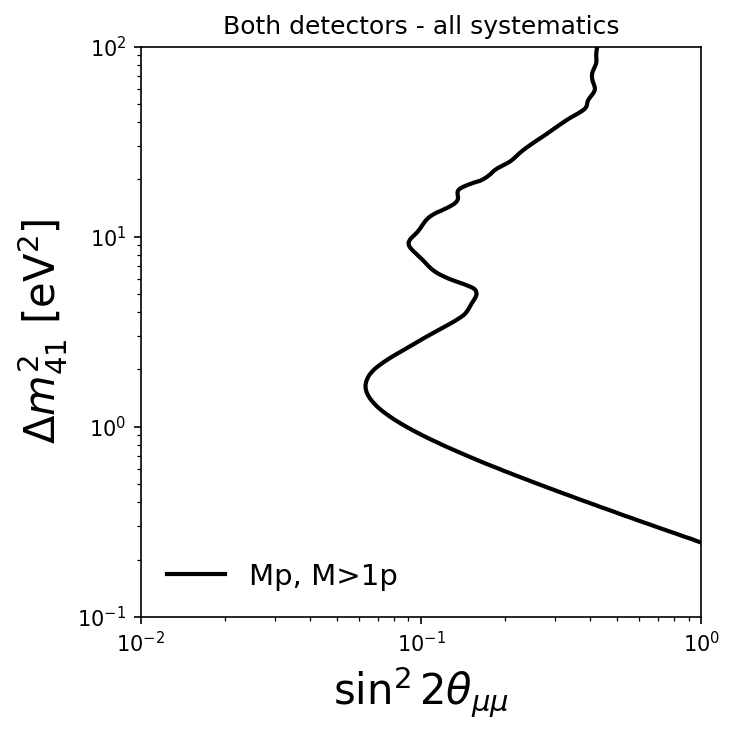

In [3]:

def to_phys(v, is_log):
    return 10**v if is_log else v


fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
if LOGX: ax.set_xscale("log")
if LOGY: ax.set_yscale("log")
ax.set_xlabel(XLABEL, fontsize=20)
ax.set_ylabel(YLABEL, fontsize=20)

legend_proxies = []
for path, label, color in zip(file_list, labels, colors):
    x, y, dchi2, meta = load_surface(path)
    if meta:
        print(f"{path}: {len(x)} points, total_fits={meta.get('total_fits')}, "
              f"min_chi2={meta.get('min_chi2'):.4g}")
    else:
        print(f"{path}: {len(x)} grid points")

    xp, yp = to_phys(x, LOGX), to_phys(y, LOGY)

    if METHOD == "tri":
        tri_t = mtri.Triangulation(x, y)
        max_edge = MAX_EDGE
        if max_edge is None:
            spacing, _ = typical_spacing(x, y)
            max_edge = MAX_EDGE_FACTOR * spacing
            print(f"{path}: auto MAX_EDGE = {max_edge:.4g} "
                  f"({MAX_EDGE_FACTOR} x median NN spacing {spacing:.4g})")
        mask_long_edges(tri_t, max_edge)
        tri_p = mtri.Triangulation(xp, yp, triangles=tri_t.triangles)
        if tri_t.mask is not None:
            tri_p.set_mask(tri_t.mask)
        ax.tricontour(tri_p, dchi2, levels=LEVELS, colors=[color], linewidths=2)

    elif METHOD == "grid":
        xg = np.linspace(x.min(), x.max(), GRID_N)
        yg = np.linspace(y.min(), y.max(), GRID_N)
        XG, YG = np.meshgrid(xg, yg)
        ZG = griddata((x, y), dchi2, (XG, YG), method=GRID_INTERP)

        far_mask, spacing = mask_far_from_data(XG, YG, x, y, MASK_DIST_FACTOR)
        print(f"{path}: median NN spacing = {spacing:.4g}, "
              f"masking cells farther than {MASK_DIST_FACTOR} x that from data "
              f"({far_mask.mean()*100:.1f}% of grid masked)")
        ZG[far_mask] = np.nan

        ax.contour(to_phys(XG, LOGX), to_phys(YG, LOGY), ZG,
                   levels=LEVELS, colors=[color], linewidths=2)
    else:
        raise ValueError(f"Unknown METHOD {METHOD!r}")

    if SHOW_POINTS:
        ax.plot(xp, yp, ".", ms=1.5, alpha=0.25, color=color, zorder=0)
    if MARK_BEST_FIT:
        i0 = int(np.argmin(dchi2))
        ax.plot(xp[i0], yp[i0], "*", ms=12, color=color,
                markeredgecolor="white", markeredgewidth=0.5)

    legend_proxies.append(Line2D([0], [0], color=color, lw=2))

leg = ax.legend(legend_proxies, labels, fontsize=14, loc="lower left")
leg.get_frame().set_linewidth(0.0)
ax.set_xlim(1e-2, 1)
ax.set_ylim(1e-1, 100)
ax.set_title("Both detectors - all systematics")
plt.tight_layout()
plt.show()